In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import matplotlib
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
matplotlib.rcParams.update(new_rc_params)
matplotlib.rcParams['pdf.fonttype'] = 42 

In [2]:
arabi_genes = pd.read_csv('/vault/transfer/passala/Module_paper_data/Medicago_vs_potato_salt_upper_tissue/medicago_gene_results.csv', index_col= 0)
arabi_ortho = pd.read_csv('/vault/transfer/passala/Module_paper_data/Medicago_vs_potato_salt_upper_tissue/medicago_ortho_trimmed_out_2_gene_families.csv', index_col= 0)
tomato_genes = pd.read_csv('/vault/transfer/passala/Module_paper_data/Medicago_vs_potato_salt_upper_tissue/potato_gene_results.csv', index_col= 0)
tomato_ortho = pd.read_csv('/vault/transfer/passala/Module_paper_data/Medicago_vs_potato_salt_upper_tissue/potato_ortho_trimmed_out_2_gene_families.csv', index_col= 0)

In [3]:
log_fc_change_evaluation_value = 1.5
log_fc_change_evaluation_value_negative = -1*log_fc_change_evaluation_value

In [4]:
tomato_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
10772at3193,3857.377618,0.888131,0.145522,6.103055,1.040602e-09,8.850650e-09
10950at3193,2367.060410,-0.194772,0.133739,-1.456353,1.452952e-01,2.006278e-01
109808at3193,122.181521,-3.637943,0.590380,-6.162040,7.181382e-10,6.297822e-09
109841at3193,1243.775892,-0.518712,0.119204,-4.351460,1.352337e-05,5.091965e-05
109843at3193,1738.062351,-0.448636,0.190996,-2.348924,1.882776e-02,3.367515e-02
...,...,...,...,...,...,...
9601at3193,1161.663834,-0.552685,0.146420,-3.774654,1.602301e-04,4.753394e-04
9609at3193,181.484672,0.005716,0.214376,0.026661,9.787300e-01,9.826220e-01
9789at3193,1315.529592,0.987404,0.156275,6.318359,2.643549e-10,2.467141e-09
9877at3193,6385.884074,1.840567,0.221504,8.309407,9.618151e-17,2.078300e-15


In [5]:
trimmed_tomato_ortho = tomato_ortho.loc[tomato_ortho.index.isin(arabi_ortho.index)]
trimmed_arabi_ortho = arabi_ortho.loc[arabi_ortho.index.isin(trimmed_tomato_ortho.index)]


In [6]:
trimmed_arabi_ortho_named = trimmed_arabi_ortho.rename(columns = {'log2FoldChange':'Arabidopsis Log2FC'})
trimmed_tomato_ortho_named = trimmed_tomato_ortho.rename(columns = {'log2FoldChange':'Tomato Log2FC'})



In [7]:
merged_ortho_df = trimmed_arabi_ortho_named[['Arabidopsis Log2FC']].merge(right = trimmed_tomato_ortho_named, left_index= True, right_index = True)

In [8]:
merged_ortho_df

,Arabidopsis Log2FC,baseMean,Tomato Log2FC,lfcSE,stat,pvalue,padj
10772at3193,-0.603083,3857.377618,0.888131,0.145522,6.103055,1.040602e-09,8.850650e-09
10950at3193,1.659283,2367.060410,-0.194772,0.133739,-1.456353,1.452952e-01,2.006278e-01
109841at3193,0.178142,1243.775892,-0.518712,0.119204,-4.351460,1.352337e-05,5.091965e-05
109843at3193,-0.727901,1738.062351,-0.448636,0.190996,-2.348924,1.882776e-02,3.367515e-02
109859at3193,-0.362878,200.929249,2.880992,0.303512,9.492194,2.262227e-21,7.588742e-20
...,...,...,...,...,...,...,...
9601at3193,0.368683,1161.663834,-0.552685,0.146420,-3.774654,1.602301e-04,4.753394e-04
9609at3193,-1.692337,181.484672,0.005716,0.214376,0.026661,9.787300e-01,9.826220e-01
9789at3193,0.142135,1315.529592,0.987404,0.156275,6.318359,2.643549e-10,2.467141e-09
9877at3193,1.132814,6385.884074,1.840567,0.221504,8.309407,9.618151e-17,2.078300e-15


In [9]:
log_fc_change_evaluation_value

1.5

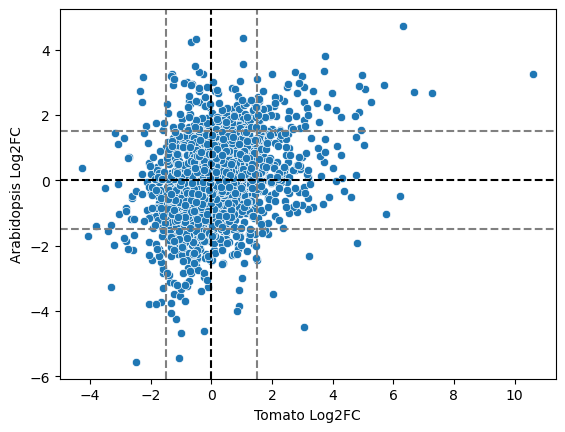

In [10]:
sns.scatterplot(data = merged_ortho_df, x ='Tomato Log2FC', y = 'Arabidopsis Log2FC' )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(x =log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(y =log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(x =log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(y =log_fc_change_evaluation_value_negative, color="grey", linestyle="--")

<Axes: xlabel='Tomato Log2FC', ylabel='Arabidopsis Log2FC'>

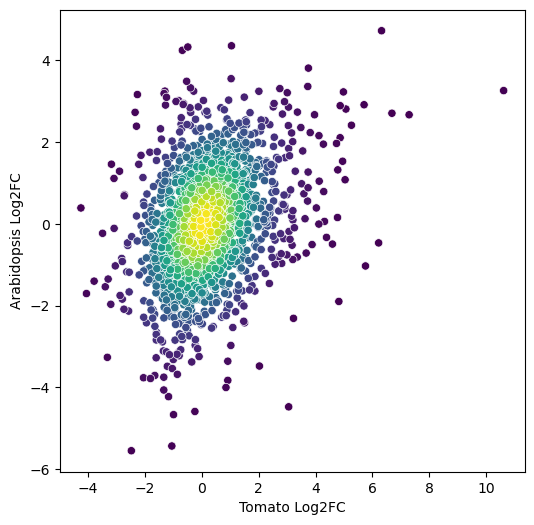

In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats



values = np.vstack([merged_ortho_df['Tomato Log2FC'], merged_ortho_df['Arabidopsis Log2FC']])
kernel = stats.gaussian_kde(values, bw_method= 1)(values)
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    data = merged_ortho_df, x ='Tomato Log2FC', y = 'Arabidopsis Log2FC',
    c=kernel,
    cmap="viridis",
    ax=ax,
)

<>:23: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:24: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:23: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:24: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
/tmp/ipykernel_3229116/2571337265.py:23: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.xlabel("Orthogroup-wise log2-fold change in $\it{Solanum\ tuberosum}$ \n under salt stress", fontsize = 12)
/tmp/ipykernel_3229116/2571337265.py:24: SyntaxWarning: "\i" is an invalid escape 

Text(0, 0.5, 'Orthogroup-wise log2-fold change in \n $\\it{Medicago\\ truncatula}$ under salt stress')

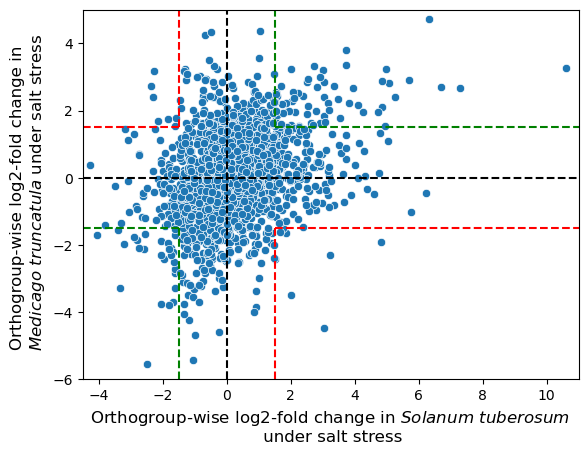

In [12]:
sns.scatterplot(x =trimmed_tomato_ortho['log2FoldChange'], y = trimmed_arabi_ortho['log2FoldChange'], )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.xlim(-4.5,11)
plt.ylim(-6,5)
# Top left quadrant - red
plt.plot([log_fc_change_evaluation_value_negative, log_fc_change_evaluation_value_negative],[log_fc_change_evaluation_value,20], color = 'r', linestyle = '--')
plt.plot([log_fc_change_evaluation_value_negative, -20],[log_fc_change_evaluation_value,log_fc_change_evaluation_value], color = 'r', linestyle = '--')

# Top right quadrant - green
plt.plot([log_fc_change_evaluation_value, 20],[log_fc_change_evaluation_value,log_fc_change_evaluation_value], color = 'g', linestyle = '--')
plt.plot([log_fc_change_evaluation_value, log_fc_change_evaluation_value],[log_fc_change_evaluation_value,20], color = 'g', linestyle = '--')

# Bottom left quadrant - green
plt.plot([log_fc_change_evaluation_value_negative, log_fc_change_evaluation_value_negative],[log_fc_change_evaluation_value_negative,-20], color = 'g', linestyle = '--')
plt.plot([log_fc_change_evaluation_value_negative, -20],[log_fc_change_evaluation_value_negative,log_fc_change_evaluation_value_negative], color = 'g', linestyle = '--')

#Bottome right quadrant - red
plt.plot([log_fc_change_evaluation_value, 20],[log_fc_change_evaluation_value_negative,log_fc_change_evaluation_value_negative], color = 'r', linestyle = '--')
plt.plot([log_fc_change_evaluation_value, log_fc_change_evaluation_value],[log_fc_change_evaluation_value_negative,-20], color = 'r', linestyle = '--')
#plt.title('Genewise potato vs medicago \n 3.3 Concordant Genes per Discordant Gene')

plt.xlabel("Orthogroup-wise log2-fold change in $\it{Solanum\ tuberosum}$ \n under salt stress", fontsize = 12)
plt.ylabel("Orthogroup-wise log2-fold change in \n $\it{Medicago\ truncatula}$ under salt stress", fontsize = 12)

In [13]:
trimmed_arabi_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
10772at3193,1920.494208,-0.603083,0.175218,-3.441905,5.776329e-04,2.488087e-03
10950at3193,906.680064,1.659283,0.251089,6.608339,3.886565e-11,4.091320e-09
109841at3193,106.107434,0.178142,0.244091,0.729817,4.655019e-01,5.818437e-01
109843at3193,2020.614100,-0.727901,0.183143,-3.974488,7.053088e-05,4.483229e-04
109859at3193,44.168932,-0.362878,0.516717,-0.702277,4.825067e-01,5.966244e-01
...,...,...,...,...,...,...
9601at3193,313.615229,0.368683,0.220084,1.675191,9.389678e-02,1.646723e-01
9609at3193,65.810657,-1.692337,0.566475,-2.987484,2.812839e-03,9.288610e-03
9789at3193,1330.229507,0.142135,0.192551,0.738166,4.604135e-01,5.774826e-01
9877at3193,959.082742,1.132814,0.179786,6.300919,2.958865e-10,2.059752e-08


In [14]:
all(trimmed_arabi_ortho.index == trimmed_tomato_ortho.index)

True

In [15]:
merged_result = pd.DataFrame(data = zip(trimmed_tomato_ortho['log2FoldChange'], trimmed_arabi_ortho['log2FoldChange']), columns = ['Tomato','Arabi'])

all_over_1 = merged_result.loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)]
all_under_1 = merged_result.loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_bottom = merged_result.loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_top = merged_result.loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']>log_fc_change_evaluation_value)]

In [16]:
merged_result['Classification'] = 'Non-substantial'
merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']>log_fc_change_evaluation_value)]= 'Substantial'

/tmp/ipykernel_3229116/2994845458.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
/tmp/ipykernel_3229116/2994845458.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because

<>:24: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:25: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:24: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:25: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
/tmp/ipykernel_3229116/1886264920.py:24: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.xlabel("Orthogroup-wise log2-fold change in $\it{Solanum\ tuberosum}$ \n under salt stress", fontsize = 12)
/tmp/ipykernel_3229116/1886264920.py:25: SyntaxWarning: "\i" is an invalid escape 

Text(0, 0.5, 'Orthogroup-wise log2-fold change in \n $\\it{Medicago\\ truncatula}$ under salt stress')

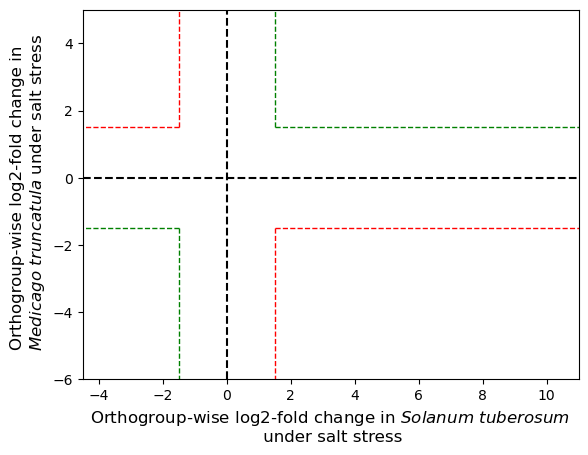

In [17]:
sns.scatterplot(data = merged_result.loc[merged_result['Classification'] == "Substantial"] , x ='Tomato', y = 'Arabi', s = 15, edgecolor = 'none')
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")

plt.xlim(-4.5,11)
plt.ylim(-6,5)
# Top left quadrant - red
plt.plot([log_fc_change_evaluation_value_negative, log_fc_change_evaluation_value_negative],[log_fc_change_evaluation_value,20], color = 'r', linestyle = '--',linewidth=1)
plt.plot([log_fc_change_evaluation_value_negative, -20],[log_fc_change_evaluation_value,log_fc_change_evaluation_value], color = 'r', linestyle = '--', linewidth=1)

# Top right quadrant - green
plt.plot([log_fc_change_evaluation_value, 20],[log_fc_change_evaluation_value,log_fc_change_evaluation_value], color = 'g', linestyle = '--', linewidth=1)
plt.plot([log_fc_change_evaluation_value, log_fc_change_evaluation_value],[log_fc_change_evaluation_value,20], color = 'g', linestyle = '--', linewidth=1)

# Bottom left quadrant - green
plt.plot([log_fc_change_evaluation_value_negative, log_fc_change_evaluation_value_negative],[log_fc_change_evaluation_value_negative,-20], color = 'g', linestyle = '--', linewidth=1)
plt.plot([log_fc_change_evaluation_value_negative, -20],[log_fc_change_evaluation_value_negative,log_fc_change_evaluation_value_negative], color = 'g', linestyle = '--', linewidth=1)

# Bottom right quadrant - red
plt.plot([log_fc_change_evaluation_value, 20],[log_fc_change_evaluation_value_negative,log_fc_change_evaluation_value_negative], color = 'r', linestyle = '--', linewidth=1)
plt.plot([log_fc_change_evaluation_value, log_fc_change_evaluation_value],[log_fc_change_evaluation_value_negative,-20], color = 'r', linestyle = '--', linewidth=1)
#plt.title('Genewise potato vs medicago \n 3.3 Concordant Genes per Discordant Gene')

plt.xlabel("Orthogroup-wise log2-fold change in $\it{Solanum\ tuberosum}$ \n under salt stress", fontsize = 12)
plt.ylabel("Orthogroup-wise log2-fold change in \n $\it{Medicago\ truncatula}$ under salt stress", fontsize = 12)
#plt.savefig('/data/passala/Plots_for_projects/Cross_species_go_groups/Potato_vs_medicago_stress_best_example/orthowise_stress.svg',dpi = 1200)

In [18]:
discord_ratio = (len(all_over_1)+len(all_under_1))/(len(discord_bottom)+len(discord_top))
discord_ratio

6.928571428571429

In [19]:
discord_bottom

,Tomato,Arabi
368,4.817739,-1.900369
419,1.863758,-1.646096
561,3.222223,-2.313676
705,1.762033,-1.511019
1484,2.023270,-3.481683
1948,3.052657,-4.480210
2107,1.672973,-1.617888


In [20]:
discord_top

,Tomato,Arabi
635,-1.832226,1.753394
683,-2.351308,2.729299
1050,-2.270780,3.165058
1319,-2.143350,1.676779
1861,-1.600198,1.552492
2092,-2.303383,2.389709
2113,-1.572518,1.765264


In [21]:
merged_result = pd.DataFrame(data = zip(trimmed_tomato_ortho['log2FoldChange'], trimmed_arabi_ortho['log2FoldChange']), columns = ['Tomato','Arabi'])
pos_thresh = 1
neg_thresh = 1
tomato_any_change = merged_result.loc[(merged_result['Tomato']>pos_thresh)|(merged_result['Tomato']<neg_thresh)]
tomato_concordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']>pos_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']<neg_thresh))]
tomato_disconcordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']<neg_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']>pos_thresh))]
percent_concordant_tomato = len(tomato_concordant_change)/len(tomato_any_change)
percent_non_discord_tomato = len(tomato_concordant_change)/(len(tomato_concordant_change+tomato_disconcordant_change))
print(percent_concordant_tomato)
print(percent_non_discord_tomato)


arabi_any_change = merged_result.loc[(merged_result['Arabi']>pos_thresh)|(merged_result['Arabi']<neg_thresh)]
arabi_concordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']>pos_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']<neg_thresh))]
arabi_disconcordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']<neg_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']>pos_thresh))]

percent_concordant_arabi = len(arabi_concordant_change)/len(arabi_any_change)
percent_non_discord_arabi = len(arabi_concordant_change)/(len(arabi_concordant_change+arabi_disconcordant_change))

print(percent_concordant_arabi)
print(percent_non_discord_arabi)

0.7957697642163661
0.7957697642163661
0.7957697642163661
0.7957697642163661


In [22]:
arabi_disconcordant_change

,Tomato,Arabi
1,-0.194772,1.659283
4,2.880992,-0.362878
15,1.226154,0.015534
25,-0.446323,1.683680
26,-1.294601,1.018913
...,...,...
2845,1.069376,-0.824767
2866,1.177426,-0.673866
2868,1.151447,0.670339
2871,-0.659074,2.922179


In [23]:
tomato_any_change

,Tomato,Arabi
0,0.888131,-0.603083
1,-0.194772,1.659283
2,-0.518712,0.178142
3,-0.448636,-0.727901
4,2.880992,-0.362878
...,...,...
2879,-0.552685,0.368683
2880,0.005716,-1.692337
2881,0.987404,0.142135
2882,1.840567,1.132814


In [24]:
tomato_concordant_change

,Tomato,Arabi
0,0.888131,-0.603083
2,-0.518712,0.178142
3,-0.448636,-0.727901
5,0.401843,0.080555
6,-0.649941,-0.197768
...,...,...
2879,-0.552685,0.368683
2880,0.005716,-1.692337
2881,0.987404,0.142135
2882,1.840567,1.132814


In [25]:
arabidopsis_tomato_nm = pd.read_csv('/vault/transfer/passala/OrthoDB_data/V_11_pairwise_maps_fixed_problem_species/medicago_to_potato_ortholog_NM.csv')

In [26]:
arabidopsis_tomato_nm

,medicago OrthoGene,potato OrthoGene,Orthogroup,medicago Symbol,potato Symbol
0,3880_0:00298d,4113_0:000e6a,10009at3193,LOC11432144,LOC102579819
1,3880_0:00042c,4113_0:0038a0,10092at3193,LOC11432413,LOC102577539
2,3880_0:0050c6,4113_0:0057e8,10147at3193,LOC11439919,LOC102600647
3,3880_0:007458,4113_0:0057e8,10147at3193,LOC25502581,LOC102600647
4,3880_0:006fc8,4113_0:000cd2,10228at3193,LOC25502274,LOC102599875
...,...,...,...,...,...
77969,3880_0:0073aa,4113_0:00186e,9942at3193,LOC11422618,LOC102586912
77970,3880_0:00388f,4113_0:002ed0,9942at3193,LOC11426138,LOC102591805
77971,3880_0:0073aa,4113_0:002ed0,9942at3193,LOC11422618,LOC102591805
77972,3880_0:00388f,4113_0:00313c,9942at3193,LOC11426138,LOC102592586


In [27]:
arabidopsis_tomato_nm = arabidopsis_tomato_nm.drop_duplicates(subset = 'medicago Symbol',)
arabidopsis_tomato_nm = arabidopsis_tomato_nm.drop_duplicates(subset = 'potato Symbol',)
arabidopsis_tomato_nm

,medicago OrthoGene,potato OrthoGene,Orthogroup,medicago Symbol,potato Symbol
0,3880_0:00298d,4113_0:000e6a,10009at3193,LOC11432144,LOC102579819
1,3880_0:00042c,4113_0:0038a0,10092at3193,LOC11432413,LOC102577539
2,3880_0:0050c6,4113_0:0057e8,10147at3193,LOC11439919,LOC102600647
4,3880_0:006fc8,4113_0:000cd2,10228at3193,LOC25502274,LOC102599875
5,3880_0:003883,4113_0:002755,10488at3193,LOC11445193,LOC102599922
...,...,...,...,...,...
77961,3880_0:002d26,4113_0:006c24,9828at3193,LOC25488891,LOC102591791
77962,3880_0:002354,4113_0:005f0f,9836at3193,LOC11432476,LOC102600007
77963,3880_0:002d72,4113_0:0026d9,9877at3193,LOC11445289,LOC102594559
77967,3880_0:00602c,4113_0:000d12,9919at3193,LOC11431644,LOC102587545


In [28]:
arabi_genes_trimmed = arabi_genes.merge(how = 'inner', left_index= True, right = arabidopsis_tomato_nm[['potato Symbol','medicago Symbol']], right_on= 'medicago Symbol')
arabi_genes_trimmed = arabi_genes_trimmed.drop_duplicates(subset = 'medicago Symbol', keep = False)
arabi_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,potato Symbol,medicago Symbol
71148,403.866867,0.011067,0.505759,0.021882,0.982542,0.988719,LOC102601062,LOC11423147
7009,127.467076,-0.375968,0.299814,-1.254001,0.209842,0.322634,LOC102591614,LOC11434621
33129,32.361682,1.724550,0.973774,1.770996,0.076561,0.146922,LOC102591284,LOC25481846
30798,126.946158,-0.922333,0.393398,-2.344526,0.019051,0.048611,LOC102577517,LOC11420842
31838,149.052981,-0.267933,0.252054,-1.062999,0.287782,0.410345,LOC102599657,LOC11425644
...,...,...,...,...,...,...,...,...
19338,1539.071118,-0.141245,0.262463,-0.538153,0.590471,0.697968,LOC102600813,LOC25480527
67769,713.069029,-0.949012,0.398570,-2.381041,0.017264,0.044944,LOC102596427,LOC25494380
56318,212.593930,-0.621380,0.375026,-1.656897,0.097540,0.177438,LOC102582522,LOC25494378
19306,331.760454,0.220814,0.368470,0.599272,0.548991,0.661764,LOC102591173,LOC11409691


In [29]:
arabidopsis_tomato_nm

,medicago OrthoGene,potato OrthoGene,Orthogroup,medicago Symbol,potato Symbol
0,3880_0:00298d,4113_0:000e6a,10009at3193,LOC11432144,LOC102579819
1,3880_0:00042c,4113_0:0038a0,10092at3193,LOC11432413,LOC102577539
2,3880_0:0050c6,4113_0:0057e8,10147at3193,LOC11439919,LOC102600647
4,3880_0:006fc8,4113_0:000cd2,10228at3193,LOC25502274,LOC102599875
5,3880_0:003883,4113_0:002755,10488at3193,LOC11445193,LOC102599922
...,...,...,...,...,...
77961,3880_0:002d26,4113_0:006c24,9828at3193,LOC25488891,LOC102591791
77962,3880_0:002354,4113_0:005f0f,9836at3193,LOC11432476,LOC102600007
77963,3880_0:002d72,4113_0:0026d9,9877at3193,LOC11445289,LOC102594559
77967,3880_0:00602c,4113_0:000d12,9919at3193,LOC11431644,LOC102587545


In [30]:
tomato_genes.head(50)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
LOC102578245,824.044875,2.065767,0.533430,3.872610,1.076760e-04,3.836325e-04
LOC102578572,396.063317,-1.916998,0.377812,-5.073953,3.896349e-07,2.500866e-06
LOC102579565,589.779005,-0.322138,0.151210,-2.130405,3.313818e-02,5.865811e-02
LOC102598415,746.107899,-0.331639,0.151165,-2.193886,2.824363e-02,5.115895e-02
LOC107060860,66.215139,-1.104732,0.344245,-3.209144,1.331308e-03,3.549327e-03
LOC102580539,375.306915,-0.366950,0.206399,-1.777866,7.542589e-02,1.194248e-01
LOC102580217,1456.350493,-0.591960,0.172677,-3.428141,6.077301e-04,1.772154e-03
LOC107060889,50.143497,0.444303,0.457847,0.970417,3.318387e-01,4.156507e-01
LOC102581788,718.197728,-0.634535,0.307534,-2.063298,3.908430e-02,6.775265e-02
LOC102601751,26.962691,-1.047351,0.623963,-1.678548,9.324025e-02,1.430093e-01


In [31]:
tomato_genes_trimmed = tomato_genes.merge(how = 'inner', left_index= True, right = arabidopsis_tomato_nm[['potato Symbol','medicago Symbol']], right_on= 'potato Symbol')
#tomato_genes_trimmed = tomato_genes_trimmed.drop_duplicates(subset = 'medicago Symbol', keep = False)
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,potato Symbol,medicago Symbol
30648,824.044875,2.065767,0.533430,3.872610,1.076760e-04,3.836325e-04,LOC102578245,LOC25483600
2988,396.063317,-1.916998,0.377812,-5.073953,3.896349e-07,2.500866e-06,LOC102578572,LOC11428583
7773,589.779005,-0.322138,0.151210,-2.130405,3.313818e-02,5.865811e-02,LOC102579565,LOC11439120
15873,746.107899,-0.331639,0.151165,-2.193886,2.824363e-02,5.115895e-02,LOC102598415,LOC11420567
58562,375.306915,-0.366950,0.206399,-1.777866,7.542589e-02,1.194248e-01,LOC102580539,LOC11422949
...,...,...,...,...,...,...,...,...
34846,252.577332,-0.699603,0.286324,-2.443399,1.454963e-02,2.881223e-02,LOC102582747,LOC25485633
12186,956.586129,0.389569,0.177681,2.192517,2.834217e-02,5.127252e-02,LOC102593803,LOC11445212
27593,125.240049,0.388335,0.307803,1.261634,2.070805e-01,2.797445e-01,LOC102599056,LOC11424039
60542,791.555382,-0.057501,0.167994,-0.342277,7.321424e-01,7.872053e-01,LOC102593479,LOC11406605


In [32]:
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,potato Symbol,medicago Symbol
30648,824.044875,2.065767,0.533430,3.872610,1.076760e-04,3.836325e-04,LOC102578245,LOC25483600
2988,396.063317,-1.916998,0.377812,-5.073953,3.896349e-07,2.500866e-06,LOC102578572,LOC11428583
7773,589.779005,-0.322138,0.151210,-2.130405,3.313818e-02,5.865811e-02,LOC102579565,LOC11439120
15873,746.107899,-0.331639,0.151165,-2.193886,2.824363e-02,5.115895e-02,LOC102598415,LOC11420567
58562,375.306915,-0.366950,0.206399,-1.777866,7.542589e-02,1.194248e-01,LOC102580539,LOC11422949
...,...,...,...,...,...,...,...,...
34846,252.577332,-0.699603,0.286324,-2.443399,1.454963e-02,2.881223e-02,LOC102582747,LOC25485633
12186,956.586129,0.389569,0.177681,2.192517,2.834217e-02,5.127252e-02,LOC102593803,LOC11445212
27593,125.240049,0.388335,0.307803,1.261634,2.070805e-01,2.797445e-01,LOC102599056,LOC11424039
60542,791.555382,-0.057501,0.167994,-0.342277,7.321424e-01,7.872053e-01,LOC102593479,LOC11406605


In [33]:
arabi_genes_trimmed = arabi_genes_trimmed.loc[arabi_genes_trimmed['medicago Symbol'].isin(tomato_genes_trimmed['medicago Symbol'])]
tomato_genes_trimmed = tomato_genes_trimmed.loc[tomato_genes_trimmed['potato Symbol'].isin(arabi_genes_trimmed['potato Symbol'])]


In [34]:
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,potato Symbol,medicago Symbol
30648,824.044875,2.065767,0.533430,3.872610,1.076760e-04,3.836325e-04,LOC102578245,LOC25483600
2988,396.063317,-1.916998,0.377812,-5.073953,3.896349e-07,2.500866e-06,LOC102578572,LOC11428583
7773,589.779005,-0.322138,0.151210,-2.130405,3.313818e-02,5.865811e-02,LOC102579565,LOC11439120
15873,746.107899,-0.331639,0.151165,-2.193886,2.824363e-02,5.115895e-02,LOC102598415,LOC11420567
58562,375.306915,-0.366950,0.206399,-1.777866,7.542589e-02,1.194248e-01,LOC102580539,LOC11422949
...,...,...,...,...,...,...,...,...
24594,494.391923,-0.222835,0.198003,-1.125411,2.604150e-01,3.395459e-01,LOC102579213,LOC11428339
69869,3037.533973,0.486411,0.215223,2.260033,2.381923e-02,4.398012e-02,LOC102582399,LOC25485634
12186,956.586129,0.389569,0.177681,2.192517,2.834217e-02,5.127252e-02,LOC102593803,LOC11445212
60542,791.555382,-0.057501,0.167994,-0.342277,7.321424e-01,7.872053e-01,LOC102593479,LOC11406605


In [35]:
tomato_genes_trimmed = (tomato_genes_trimmed.set_index('medicago Symbol')
          .reindex(arabi_genes_trimmed.set_index('medicago Symbol').index)
          .reset_index()
       )

In [36]:
tomato_genes_trimmed

,medicago Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,potato Symbol
0,LOC11423147,357.005137,-0.107202,0.231537,-0.462998,6.433654e-01,7.109155e-01,LOC102601062
1,LOC11434621,1123.133258,0.534209,0.205210,2.603229,9.235019e-03,1.939462e-02,LOC102591614
2,LOC25481846,927.476551,-0.242976,0.152954,-1.588564,1.121589e-01,1.670704e-01,LOC102591284
3,LOC11420842,142.970741,-1.101707,0.380751,-2.893507,3.809655e-03,8.925798e-03,LOC102577517
4,LOC11425644,463.920344,0.102309,0.198489,0.515439,6.062466e-01,6.786002e-01,LOC102599657
...,...,...,...,...,...,...,...,...
8038,LOC25480527,656.394063,1.302941,0.212768,6.123772,9.138593e-10,9.636253e-09,LOC102600813
8039,LOC25494380,427.966422,-0.262303,0.248904,-1.053832,2.919598e-01,3.736159e-01,LOC102596427
8040,LOC25494378,1336.037173,-0.369941,0.209588,-1.765089,7.754878e-02,1.222924e-01,LOC102582522
8041,LOC11409691,2163.871694,-0.387919,0.288595,-1.344165,1.788949e-01,2.471611e-01,LOC102591173


In [37]:
arabi_genes_trimmed = arabi_genes_trimmed.reset_index()

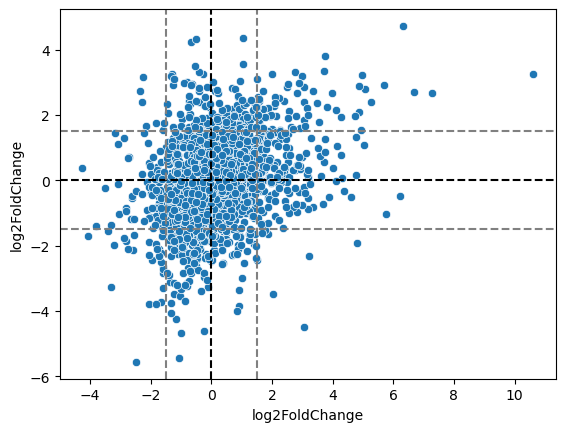

In [38]:
sns.scatterplot(x =trimmed_tomato_ortho['log2FoldChange'], y = trimmed_arabi_ortho['log2FoldChange'], )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")

<>:22: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:23: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:22: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:23: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
/tmp/ipykernel_3229116/3242661774.py:22: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.xlabel("Genewise log2-fold change in $\it{Solanum\ tuberosum}$ \n under salt stress", fontsize = 12)
/tmp/ipykernel_3229116/3242661774.py:23: SyntaxWarning: "\i" is an invalid escape sequenc

Text(0, 0.5, 'Genewise log2-fold change in \n $\\it{Medicago\\ truncatula}$ under salt stress')

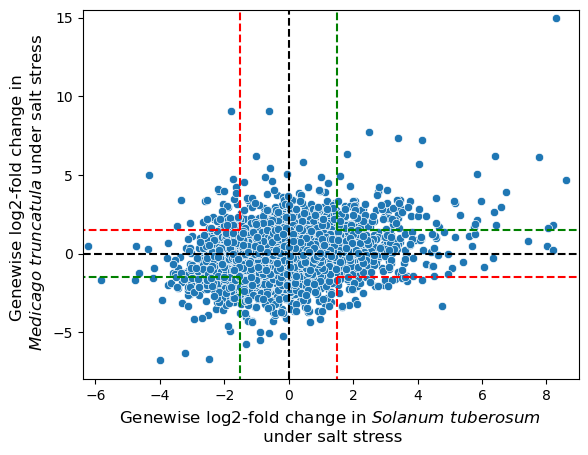

In [39]:
sns.scatterplot(x =tomato_genes_trimmed['log2FoldChange'], y = arabi_genes_trimmed['log2FoldChange'])
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
# Top left quadrant - red
plt.plot([log_fc_change_evaluation_value_negative, log_fc_change_evaluation_value_negative],[log_fc_change_evaluation_value,20], color = 'r', linestyle = '--')
plt.plot([log_fc_change_evaluation_value_negative, -20],[log_fc_change_evaluation_value,log_fc_change_evaluation_value], color = 'r', linestyle = '--')

# Top right quadrant - green
plt.plot([log_fc_change_evaluation_value, 20],[log_fc_change_evaluation_value,log_fc_change_evaluation_value], color = 'g', linestyle = '--')
plt.plot([log_fc_change_evaluation_value, log_fc_change_evaluation_value],[log_fc_change_evaluation_value,20], color = 'g', linestyle = '--')

# Bottom left quadrant - green
plt.plot([log_fc_change_evaluation_value_negative, log_fc_change_evaluation_value_negative],[log_fc_change_evaluation_value_negative,-20], color = 'g', linestyle = '--')
plt.plot([log_fc_change_evaluation_value_negative, -20],[log_fc_change_evaluation_value_negative,log_fc_change_evaluation_value_negative], color = 'g', linestyle = '--')

#Bottome right quadrant - red
plt.plot([log_fc_change_evaluation_value, 20],[log_fc_change_evaluation_value_negative,log_fc_change_evaluation_value_negative], color = 'r', linestyle = '--')
plt.plot([log_fc_change_evaluation_value, log_fc_change_evaluation_value],[log_fc_change_evaluation_value_negative,-20], color = 'r', linestyle = '--')
#plt.title('Genewise potato vs medicago \n 3.3 Concordant Genes per Discordant Gene')
plt.xlim(-6.4,9)
plt.ylim(-8,15.5)
plt.xlabel("Genewise log2-fold change in $\it{Solanum\ tuberosum}$ \n under salt stress", fontsize = 12)
plt.ylabel("Genewise log2-fold change in \n $\it{Medicago\ truncatula}$ under salt stress", fontsize = 12)

<Axes: xlabel='log2FoldChange', ylabel='log2FoldChange'>

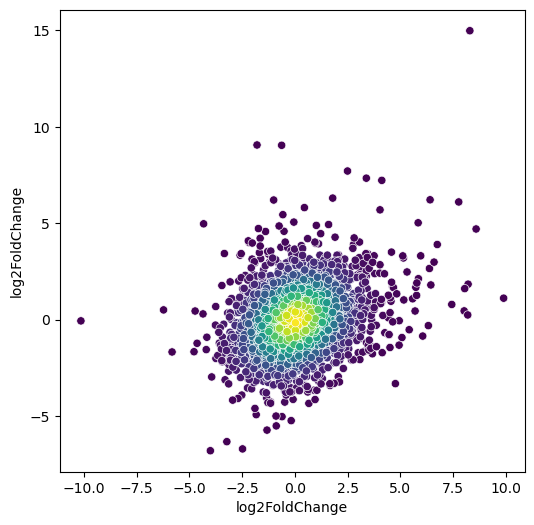

In [40]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats



values = np.vstack([tomato_genes_trimmed['log2FoldChange'], arabi_genes_trimmed['log2FoldChange']])
kernel = stats.gaussian_kde(values, bw_method= 1)(values)
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    x=tomato_genes_trimmed['log2FoldChange'],
    y=arabi_genes_trimmed['log2FoldChange'],
    c=kernel,
    cmap="viridis",
    ax=ax,
)

<>:28: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:29: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:28: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:29: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
/tmp/ipykernel_3229116/3734108788.py:28: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.xlabel("Genewise log2-fold change in $\it{Solanum\ tuberosum}$ \n under salt stress", fontsize = 12)
/tmp/ipykernel_3229116/3734108788.py:29: SyntaxWarning: "\i" is an invalid escape sequenc

Text(0, 0.5, 'Genewise log2-fold change in \n $\\it{Medicago\\ truncatula}$ under salt stress')

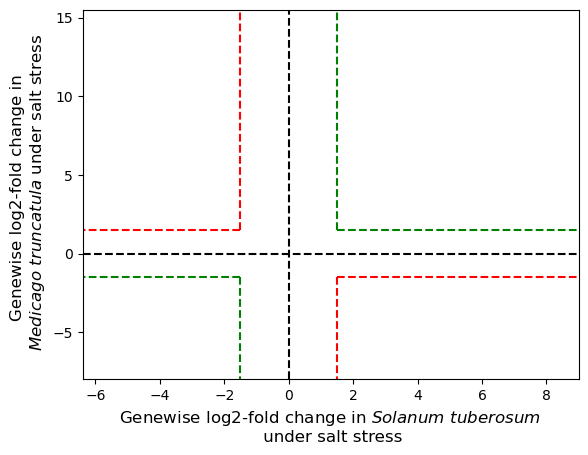

In [41]:
sns.scatterplot(
    x=tomato_genes_trimmed['log2FoldChange'],
    y=arabi_genes_trimmed['log2FoldChange'],
    c=kernel,
    cmap="viridis",
    ax=ax,
)
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
# Top left quadrant - red
plt.plot([log_fc_change_evaluation_value_negative, log_fc_change_evaluation_value_negative],[log_fc_change_evaluation_value,20], color = 'r', linestyle = '--')
plt.plot([log_fc_change_evaluation_value_negative, -20],[log_fc_change_evaluation_value,log_fc_change_evaluation_value], color = 'r', linestyle = '--')

# Top right quadrant - green
plt.plot([log_fc_change_evaluation_value, 20],[log_fc_change_evaluation_value,log_fc_change_evaluation_value], color = 'g', linestyle = '--')
plt.plot([log_fc_change_evaluation_value, log_fc_change_evaluation_value],[log_fc_change_evaluation_value,20], color = 'g', linestyle = '--')

# Bottom left quadrant - green
plt.plot([log_fc_change_evaluation_value_negative, log_fc_change_evaluation_value_negative],[log_fc_change_evaluation_value_negative,-20], color = 'g', linestyle = '--')
plt.plot([log_fc_change_evaluation_value_negative, -20],[log_fc_change_evaluation_value_negative,log_fc_change_evaluation_value_negative], color = 'g', linestyle = '--')

#Bottome right quadrant - red
plt.plot([log_fc_change_evaluation_value, 20],[log_fc_change_evaluation_value_negative,log_fc_change_evaluation_value_negative], color = 'r', linestyle = '--')
plt.plot([log_fc_change_evaluation_value, log_fc_change_evaluation_value],[log_fc_change_evaluation_value_negative,-20], color = 'r', linestyle = '--')
#plt.title('Genewise potato vs medicago \n 3.3 Concordant Genes per Discordant Gene')
plt.xlim(-6.4,9)
plt.ylim(-8,15.5)
plt.xlabel("Genewise log2-fold change in $\it{Solanum\ tuberosum}$ \n under salt stress", fontsize = 12)
plt.ylabel("Genewise log2-fold change in \n $\it{Medicago\ truncatula}$ under salt stress", fontsize = 12)

In [42]:
new_merged_result = pd.DataFrame(data = zip(tomato_genes_trimmed['log2FoldChange'], arabi_genes_trimmed['log2FoldChange']), columns = ['Tomato','Arabi'])

all_over_1 = new_merged_result.loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]
all_under_1 = new_merged_result.loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_bottom = new_merged_result.loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_top = new_merged_result.loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]

In [43]:
new_merged_result['Classification'] = 'Non-substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]= 'Substantial'

/tmp/ipykernel_3229116/1856289886.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
/tmp/ipykernel_3229116/1856289886.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Ser

<>:23: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:24: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:23: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:24: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
/tmp/ipykernel_3229116/3682610168.py:23: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.xlabel("Genewise log2-fold change in $\it{Solanum\ tuberosum}$ \n under salt stress", fontsize = 12)
/tmp/ipykernel_3229116/3682610168.py:24: SyntaxWarning: "\i" is an invalid escape sequenc

Text(0, 0.5, 'Genewise log2-fold change in \n $\\it{Medicago\\ truncatula}$ under salt stress')

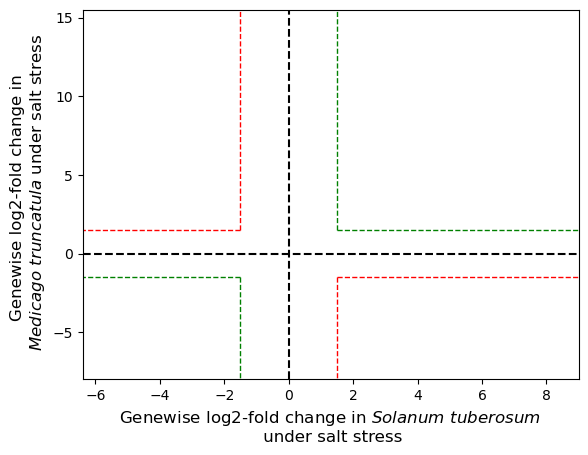

In [44]:
sns.scatterplot(data = new_merged_result.loc[new_merged_result['Classification'] == "Substantial"] , x ='Tomato', y = 'Arabi', s = 15, edgecolor = None )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
#plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
# Top left quadrant - red
plt.plot([log_fc_change_evaluation_value_negative, log_fc_change_evaluation_value_negative],[log_fc_change_evaluation_value,20], color = 'r', linestyle = '--', linewidth=1)
plt.plot([log_fc_change_evaluation_value_negative, -20],[log_fc_change_evaluation_value,log_fc_change_evaluation_value], color = 'r', linestyle = '--', linewidth=1)

# Top right quadrant - green
plt.plot([log_fc_change_evaluation_value, 20],[log_fc_change_evaluation_value,log_fc_change_evaluation_value], color = 'g', linestyle = '--', linewidth=1)
plt.plot([log_fc_change_evaluation_value, log_fc_change_evaluation_value],[log_fc_change_evaluation_value,20], color = 'g', linestyle = '--', linewidth=1)

# Bottom left quadrant - green
plt.plot([log_fc_change_evaluation_value_negative, log_fc_change_evaluation_value_negative],[log_fc_change_evaluation_value_negative,-20], color = 'g', linestyle = '--', linewidth=1)
plt.plot([log_fc_change_evaluation_value_negative, -20],[log_fc_change_evaluation_value_negative,log_fc_change_evaluation_value_negative], color = 'g', linestyle = '--', linewidth=1)

# Bottom right quadrant - red
plt.plot([log_fc_change_evaluation_value, 20],[log_fc_change_evaluation_value_negative,log_fc_change_evaluation_value_negative], color = 'r', linestyle = '--', linewidth=1)
plt.plot([log_fc_change_evaluation_value, log_fc_change_evaluation_value],[log_fc_change_evaluation_value_negative,-20], color = 'r', linestyle = '--', linewidth=1)
#plt.title('Genewise potato vs medicago \n 3.3 Concordant Genes per Discordant Gene')
plt.xlim(-6.4,9)
plt.ylim(-8,15.5)
plt.xlabel("Genewise log2-fold change in $\it{Solanum\ tuberosum}$ \n under salt stress", fontsize = 12)
plt.ylabel("Genewise log2-fold change in \n $\it{Medicago\ truncatula}$ under salt stress", fontsize = 12)
#plt.savefig('/data/passala/Plots_for_projects/Cross_species_go_groups/Potato_vs_medicago_stress_best_example/genewise_stress.svg',dpi = 1200)

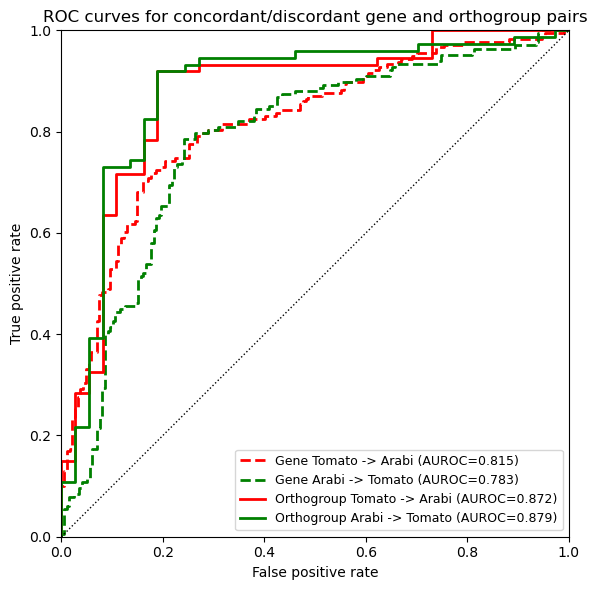

In [45]:
from sklearn.metrics import roc_curve


def calculate_threshold_exceedance_auroc(source_log2fc, target_log2fc, evaluation_threshold):
    paired_values = pd.DataFrame(
        {
            "source_log2fc": source_log2fc,
            "target_log2fc": target_log2fc,
        }
    ).dropna()

    substantial_pair_mask = (
        paired_values["source_log2fc"].abs() >= evaluation_threshold
    ) & (paired_values["target_log2fc"].abs() >= evaluation_threshold)
    paired_values = paired_values.loc[substantial_pair_mask].copy()

    paired_values = paired_values.loc[
        paired_values["source_log2fc"] * paired_values["target_log2fc"] != 0
    ].copy()
    paired_values["pair_class"] = "discordant"
    paired_values.loc[
        paired_values["source_log2fc"] * paired_values["target_log2fc"] > 0,
        "pair_class",
    ] = "concordant"

    target_positive_direction = paired_values["target_log2fc"] >= evaluation_threshold
    n_concordant = int((paired_values["pair_class"] == "concordant").sum())
    n_discordant = int((paired_values["pair_class"] == "discordant").sum())

    if target_positive_direction.nunique() < 2:
        return {
            "summary": {
                "auroc": float("nan"),
                "n_pairs": len(paired_values),
                "n_target_positive": int(target_positive_direction.sum()),
                "n_target_negative": int((~target_positive_direction).sum()),
                "n_concordant": n_concordant,
                "n_discordant": n_discordant,
            },
            "roc_curve": pd.DataFrame({"fpr": [0.0, 1.0], "tpr": [0.0, 1.0]}),
        }

    source_score_ranks = stats.rankdata(paired_values["source_log2fc"] )
    n_positive = int(target_positive_direction.sum())
    n_negative = int((~target_positive_direction).sum())
    positive_rank_sum = source_score_ranks[target_positive_direction.to_numpy()].sum()
    auroc = (
        positive_rank_sum - (n_positive * (n_positive + 1) / 2)
    ) / (n_positive * n_negative)
    fpr, tpr, _ = roc_curve(
        target_positive_direction.astype(int), paired_values["source_log2fc"]
    )

    return {
        "summary": {
            "auroc": auroc,
            "n_pairs": len(paired_values),
            "n_target_positive": n_positive,
            "n_target_negative": n_negative,
            "n_concordant": n_concordant,
            "n_discordant": n_discordant,
        },
        "roc_curve": pd.DataFrame({"fpr": fpr, "tpr": tpr}),
    }


def summarize_bidirectional_threshold_aurocs(
    paired_log2fc_df, left_species_label, right_species_label, evaluation_threshold, pair_type
    ):
    left_to_right = calculate_threshold_exceedance_auroc(
        source_log2fc=paired_log2fc_df[left_species_label],
        target_log2fc=paired_log2fc_df[right_species_label],
        evaluation_threshold=evaluation_threshold,
    )
    right_to_left = calculate_threshold_exceedance_auroc(
        source_log2fc=paired_log2fc_df[right_species_label],
        target_log2fc=paired_log2fc_df[left_species_label],
        evaluation_threshold=evaluation_threshold,
    )

    summary_df = pd.DataFrame(
        [
            {
                "pair_type": pair_type,
                "prediction_direction": f"{left_species_label} -> {right_species_label}",
                **left_to_right["summary"],
            },
            {
                "pair_type": pair_type,
                "prediction_direction": f"{right_species_label} -> {left_species_label}",
                **right_to_left["summary"],
            },
        ]
    )
    roc_curve_df = pd.concat(
        [
            left_to_right["roc_curve"].assign(
                pair_type=pair_type,
                prediction_direction=f"{left_species_label} -> {right_species_label}",
            ),
            right_to_left["roc_curve"].assign(
                pair_type=pair_type,
                prediction_direction=f"{right_species_label} -> {left_species_label}",
            ),
        ],
        ignore_index=True,
    )

    return summary_df, roc_curve_df
gene_log2fc_pairs = pd.DataFrame(
    {
        "Tomato": tomato_genes_trimmed["log2FoldChange"].to_numpy(),
        "Arabi": arabi_genes_trimmed["log2FoldChange"].to_numpy(),
    }
)

orthogroup_log2fc_pairs = pd.DataFrame(
    {
        "Tomato": trimmed_tomato_ortho["log2FoldChange"].to_numpy(),
        "Arabi": trimmed_arabi_ortho["log2FoldChange"].to_numpy(),
    }
)

gene_auroc_summary, gene_roc_curves = summarize_bidirectional_threshold_aurocs(
    paired_log2fc_df=gene_log2fc_pairs,
    left_species_label="Tomato",
    right_species_label="Arabi",
    evaluation_threshold=log_fc_change_evaluation_value,
    pair_type="Gene",
)

orthogroup_auroc_summary, orthogroup_roc_curves = summarize_bidirectional_threshold_aurocs(
    paired_log2fc_df=orthogroup_log2fc_pairs,
    left_species_label="Tomato",
    right_species_label="Arabi",
    evaluation_threshold=log_fc_change_evaluation_value,
    pair_type="Orthogroup",
)

bidirectional_auroc_summary = pd.concat(
    [gene_auroc_summary, orthogroup_auroc_summary],
    ignore_index=True,
 )

bidirectional_roc_curves = pd.concat(
    [gene_roc_curves, orthogroup_roc_curves],
    ignore_index=True,
)


bidirectional_auroc_summary[[
    "pair_type",
    "prediction_direction",
    "auroc",
    "n_pairs",
    "n_concordant",
    "n_discordant",
    "n_target_positive",
    "n_target_negative",
]].round({"auroc": 3})
plot_colors = {
    "Tomato -> Arabi": "red",
    "Arabi -> Tomato": "green",
}
plot_linestyles = {
    "Orthogroup": "-",
    "Gene": "--",
}

plt.figure(figsize=(6, 6))
for _, summary_row in bidirectional_auroc_summary.iterrows():
    curve_subset = bidirectional_roc_curves.loc[
        (bidirectional_roc_curves["pair_type"] == summary_row["pair_type"])
        & (
            bidirectional_roc_curves["prediction_direction"]
            == summary_row["prediction_direction"]
        )
    ]
    plt.plot(
        curve_subset["fpr"],
        curve_subset["tpr"],
        color=plot_colors[summary_row["prediction_direction"]],
        linestyle=plot_linestyles[summary_row["pair_type"]],
        linewidth=2,
        label=(
            f"{summary_row['pair_type']} {summary_row['prediction_direction']} "
            f"(AUROC={summary_row['auroc']:.3f})"
        ),
    )

plt.plot([0, 1], [0, 1], color="black", linestyle=":", linewidth=1)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves for concordant/discordant gene and orthogroup pairs")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()

In [46]:
def get_ncbi_clean_og2gene_for_species(
    species_1, og2genes_only_cococonet, ncbi_mapping
):

    species_1_name = species_1

    first_species_ortho_groups = og2genes_only_cococonet.loc[
        og2genes_only_cococonet["Species"] == species_1
    ]
    shared_orthogroups = first_species_ortho_groups["Orthogroup"].unique()

    list_of_orthogene_pds = []
    for orthogroup in tq.tqdm(
        shared_orthogroups, desc="inner_loop", position=0, leave=False
    ):
        species_1_genes = (
            first_species_ortho_groups["Gene"]
            .loc[first_species_ortho_groups["Orthogroup"] == orthogroup]
            .to_list()
        )
        all_gene_combos = species_1_genes
        current_orthogroup_pd = pd.DataFrame(
            columns=[f"{species_1_name} OrthoGene"], data=all_gene_combos
        )
        current_orthogroup_pd["Orthogroup"] = orthogroup
        list_of_orthogene_pds.append(current_orthogroup_pd)

    final_species_lineup = pd.concat(list_of_orthogene_pds)
    ncbi_added_once = final_species_lineup.merge(
        right=ncbi_mapping[["Orthodb Gene", "Symbol"]],
        right_on="Orthodb Gene",
        left_on=f"{species_1_name} OrthoGene",
    )
    ncbi_added_once_clean = ncbi_added_once.drop(columns="Orthodb Gene")
    return ncbi_added_once_clean
og_groups = pd.read_csv(
    "/vault/transfer/passala/OrthoDB_data/NCBI_data/og_2_Genes_with_ncbi_symbol.csv"
)
og_groups
ncbi_mapping = pd.read_csv(
    "/vault/transfer/passala/OrthoDB_data/NCBI_data/merged_ncbi_to_orthodb_fixed_non_genesymbol.csv"
)

In [47]:
import tqdm as tq
arabi_og = get_ncbi_clean_og2gene_for_species(
    3880, og_groups, ncbi_mapping=ncbi_mapping
)

inner_loop:   0%|          | 0/13846 [00:00<?, ?it/s]

In [48]:
symbol_col = tomato_genes_trimmed.columns[0]
merged_gene_df = (
    arabi_genes_trimmed.rename(columns={"log2FoldChange": "Arabidopsis Log2FC"})
    [[symbol_col, "Arabidopsis Log2FC"]]
    .merge(
        right=arabi_og[["Symbol", "Orthogroup"]].drop_duplicates(
            subset="Symbol", keep="first"
        ),
        left_on=symbol_col,
        right_on="Symbol",
        how="left",
    )
    .drop(columns="Symbol")
    .merge(
        right=tomato_genes_trimmed.rename(
            columns={"log2FoldChange": "Tomato Log2FC"}
        )[[symbol_col, "Tomato Log2FC"]],
        on=symbol_col,
        how="inner",
    )
    [["Orthogroup", symbol_col, "Arabidopsis Log2FC", "Tomato Log2FC"]]
    .set_index(symbol_col)
)


gene_threshold = 1.5

merged_gene_df_arabi_threshold = merged_gene_df.loc[
    merged_gene_df["Arabidopsis Log2FC"].abs() > gene_threshold
] .copy()

merged_gene_df_arabi_threshold["Orthogroup Arabidopsis Log2FC"] = merged_gene_df_arabi_threshold[
    "Orthogroup"
] .map(merged_ortho_df["Arabidopsis Log2FC"] )

merged_gene_df_arabi_threshold[
    "Orthogroup exceeds Arabidopsis threshold in same direction"
] = (
    (merged_gene_df_arabi_threshold["Arabidopsis Log2FC"] > gene_threshold)
    & (merged_gene_df_arabi_threshold["Orthogroup Arabidopsis Log2FC"] > gene_threshold)
) | (
    (merged_gene_df_arabi_threshold["Arabidopsis Log2FC"] < -gene_threshold)
    & (merged_gene_df_arabi_threshold["Orthogroup Arabidopsis Log2FC"] < -gene_threshold)
)

merged_gene_df_arabi_threshold
merged_gene_df_arabi_threshold[
    "Tomato exceeds threshold in same direction"
 ] = (
    (merged_gene_df_arabi_threshold["Arabidopsis Log2FC"] > gene_threshold)
    & (merged_gene_df_arabi_threshold["Tomato Log2FC"] > gene_threshold)
) | (
    (merged_gene_df_arabi_threshold["Arabidopsis Log2FC"] < -gene_threshold)
    & (merged_gene_df_arabi_threshold["Tomato Log2FC"] < -gene_threshold)
)

merged_gene_df_arabi_threshold

,Orthogroup,Arabidopsis Log2FC,Tomato Log2FC,Orthogroup Arabidopsis Log2FC,Orthogroup exceeds Arabidopsis threshold in same direction,Tomato exceeds threshold in same direction
medicago Symbol,,,,,,
LOC25481846,578065at3193,1.724550,-0.242976,NaN,False,False
LOC11429785,122754at3193,2.901266,-0.755473,1.869497,True,False
LOC11429786,127750at3193,1.657134,-0.130062,NaN,False,False
LOC25481855,604142at3193,1.631116,1.268983,0.915108,False,False
LOC11429788,886022at3193,-2.615947,-0.928820,NaN,False,False
...,...,...,...,...,...,...
LOC11426510,130310at3193,-2.019621,-1.145926,NaN,False,False
LOC11412397,77948at3193,1.625503,-2.407857,NaN,False,False
LOC11416750,32439at3193,-1.518617,-1.171190,NaN,False,False


In [49]:
fisher_input_df = merged_gene_df_arabi_threshold[[
    "Orthogroup exceeds Arabidopsis threshold in same direction",
    "Tomato exceeds threshold in same direction",
]].copy()

fisher_contingency_table = pd.crosstab(
    fisher_input_df["Orthogroup exceeds Arabidopsis threshold in same direction"],
    fisher_input_df["Tomato exceeds threshold in same direction"],
).reindex(index=[False, True], columns=[False, True], fill_value=0)

fisher_odds_ratio, fisher_p_value = stats.fisher_exact(
    fisher_contingency_table.to_numpy(),
    alternative="greater",
)

fisher_exact_summary = pd.DataFrame(
    {
        "odds_ratio": [fisher_odds_ratio],
        "p_value": [fisher_p_value],
    }
)

fisher_contingency_table, fisher_exact_summary

(Tomato exceeds threshold in same direction          False  True 
 Orthogroup exceeds Arabidopsis threshold in sam...              
 False                                                 798    231
 True                                                  141     49,
    odds_ratio   p_value
 0    1.200516  0.180376)

In [50]:
non_missing_orthogroup_df = merged_gene_df_arabi_threshold.dropna(
    subset=["Orthogroup Arabidopsis Log2FC"]
 ).copy()

non_missing_fisher_input_df = non_missing_orthogroup_df[[
    "Orthogroup exceeds Arabidopsis threshold in same direction",
    "Tomato exceeds threshold in same direction",
]].copy()

non_missing_fisher_contingency_table = pd.crosstab(
    non_missing_fisher_input_df[
        "Orthogroup exceeds Arabidopsis threshold in same direction"
    ],
    non_missing_fisher_input_df["Tomato exceeds threshold in same direction"],
).reindex(index=[False, True], columns=[False, True], fill_value=0)

non_missing_fisher_odds_ratio, non_missing_fisher_p_value = stats.fisher_exact(
    non_missing_fisher_contingency_table.to_numpy(),
    alternative="greater",
)

non_missing_fisher_summary = pd.DataFrame(
    {
        "odds_ratio": [non_missing_fisher_odds_ratio],
        "p_value": [non_missing_fisher_p_value],
        "n_genes": [len(non_missing_orthogroup_df)],
    }
)

readable_non_missing_fisher_table = non_missing_fisher_contingency_table.rename(
    index={
        False: "Orthogroup below / opposite direction",
        True: "Orthogroup exceeds in same direction",
    },
    columns={
        False: "Tomato below / opposite direction",
        True: "Tomato exceeds in same direction",
    },
)

readable_non_missing_fisher_table["Row total"] = readable_non_missing_fisher_table.sum(
    axis=1
)
readable_non_missing_fisher_table.loc["Column total"] = readable_non_missing_fisher_table.sum(
    axis=0
)

display(readable_non_missing_fisher_table)
non_missing_fisher_summary

Tomato exceeds threshold in same direction,Tomato below / opposite direction,Tomato exceeds in same direction,Row total
Orthogroup exceeds Arabidopsis threshold in same direction,,,
Orthogroup below / opposite direction,220,29,249
Orthogroup exceeds in same direction,141,49,190
Column total,361,78,439


,odds_ratio,p_value,n_genes
0,2.636341,0.000106,439


In [44]:
discord_ratio = (len(all_over_1)+len(all_under_1))/(len(discord_bottom)+len(discord_top))
discord_ratio

3.2941176470588234

In [ ]:
all_over_1

In [ ]:
all_under_1

In [ ]:
merged_result

In [ ]:
merged_result = pd.DataFrame(data = zip(tomato_genes_trimmed['log2FoldChange'], arabi_genes_trimmed['log2FoldChange']), columns = ['Tomato','Arabi'])

pos_thresh = 0
neg_thresh = 0
tomato_any_change = merged_result.loc[(merged_result['Tomato']>pos_thresh)|(merged_result['Tomato']<neg_thresh)]
tomato_concordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']>pos_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']<neg_thresh))]
tomato_disconcordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']<neg_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']>pos_thresh))]
percent_concordant_tomato = len(tomato_concordant_change)/len(tomato_any_change)
percent_non_discord_tomato = len(tomato_concordant_change)/(len(tomato_concordant_change+tomato_disconcordant_change))
print(percent_concordant_tomato)
print(percent_non_discord_tomato)


arabi_any_change = merged_result.loc[(merged_result['Arabi']>pos_thresh)|(merged_result['Arabi']<neg_thresh)]
arabi_concordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']>pos_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']<neg_thresh))]
arabi_disconcordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']<neg_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']>pos_thresh))]

percent_concordant_arabi = len(arabi_concordant_change)/len(arabi_any_change)
percent_non_discord_arabi = len(arabi_concordant_change)/(len(arabi_concordant_change+arabi_disconcordant_change))

print(percent_concordant_arabi)
print(percent_non_discord_arabi)

In [ ]:
stats.spearmanr(a=tomato_genes_trimmed['log2FoldChange'], b = arabi_genes_trimmed['log2FoldChange'] )

In [ ]:
down = tomato_genes_trimmed[
    (tomato_genes_trimmed["log2FoldChange"] <= -2) & (tomato_genes_trimmed["padj"] <= 0.001)
]
up = tomato_genes_trimmed[
    (tomato_genes_trimmed["log2FoldChange"] >= 2) & (tomato_genes_trimmed["padj"] <= 0.001)
]
down_arabi = arabi_genes_trimmed[
    (arabi_genes_trimmed["log2FoldChange"] <= -2)
    & (arabi_genes_trimmed["padj"] <= 0.001)
]
up_arabi = arabi_genes_trimmed[
    (arabi_genes_trimmed["log2FoldChange"] >= 2) & (arabi_genes_trimmed["padj"] <= 0.001)
]

In [ ]:
down_arabi_ortho = trimmed_arabi_ortho[
    (trimmed_arabi_ortho["log2FoldChange"] <= -2)
    & (trimmed_arabi_ortho["padj"] <= 0.001)
]
up_arabi_ortho = trimmed_arabi_ortho[
    (trimmed_arabi_ortho["log2FoldChange"] >= 2) & (trimmed_arabi_ortho["padj"] <= 0.001)]

down_ortho = trimmed_tomato_ortho[
    (trimmed_tomato_ortho["log2FoldChange"] <= -2) & (trimmed_tomato_ortho["padj"] <= 0.001)
]
up_ortho = trimmed_tomato_ortho[
    (trimmed_tomato_ortho["log2FoldChange"] >= 2) & (trimmed_tomato_ortho["padj"] <= 0.001)
]

In [ ]:
len(up_arabi_ortho.merge(how = "inner", right_index = True, left_index= True, right = up_ortho))

In [ ]:
up_ortho

In [ ]:
up_arabi_ortho

In [ ]:
up

In [ ]:
up_arabi

In [ ]:
up_arabi.merge(how = "inner", on = 'arabidopsis Symbol', right = up)